# JOB MARKET AND UNEMPLOYMENT DATASET

This dataset contains detailed records of job market activity across various U.S. metropolitan areas, including economic, demographic, and temporal factors. The records include the date, location, unemployment rate, volume of job postings, a list of in-demand skills, average age, and college degree percentage. You will analyze this data to understand temporal and geographical patterns in unemployment and job creation, identify key skill demands and their shifts over time, and investigate the influence of demographic factors (average age and education level) on the overall job market health of each city. You will also summarize key statistics such as the average unemployment rate, the percentage of highly educated workers, and the correlation between education and employment. The goal is to gain actionable insights into local economic drivers, forecast market stability, and find areas where policymakers and educational institutions can improve training programs or prevent high unemployment effectively.

In [639]:
# IMPORTING THE LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

##### Importing the dataset

In [640]:
df=pd.read_csv(r"C:\Users\AJEER\Downloads\job_market_unemployment_trends.csv")

##### First five rows

In [641]:
print(df)

       id        date       location  unemployment_rate  job_postings  \
0       1  2023-10-07        Houston                6.8          4894   
1       2  2025-05-24     Washington               11.1          2695   
2       3  2024-09-28        Chicago                7.3          1174   
3       4  2024-12-28   Indianapolis               11.2          3708   
4       5  2023-09-10       New York               13.7           268   
..    ...         ...            ...                ...           ...   
995   996  2023-11-07   Jacksonville                8.9          4127   
996   997  2024-02-27         Austin                8.3          1203   
997   998  2023-10-13         Denver                4.9           184   
998   999  2024-05-08         Dallas                6.7          3236   
999  1000  2025-07-08  San Francisco                5.8           350   

                                      in_demand_skills  average_age  \
0              Agile Methodologies, Project Manageme

##### Last five rows

In [642]:
print(df.tail(5))

       id        date       location  unemployment_rate  job_postings  \
995   996  2023-11-07   Jacksonville                8.9          4127   
996   997  2024-02-27         Austin                8.3          1203   
997   998  2023-10-13         Denver                4.9           184   
998   999  2024-05-08         Dallas                6.7          3236   
999  1000  2025-07-08  San Francisco                5.8           350   

                                      in_demand_skills  average_age  \
995                        UX/UI Design, Data Analysis           43   
996  Project Management, JavaScript, Agile Methodol...           46   
997  JavaScript, Project Management, Machine Learni...           25   
998  Project Management, Digital Marketing, Sales, ...           25   
999  JavaScript, Customer Service, Agile Methodolog...           32   

     college_degree_percentage  
995                         84  
996                         41  
997                         68  
99

##### Checking the data types

In [643]:
print(df.dtypes)

id                             int64
date                          object
location                      object
unemployment_rate            float64
job_postings                   int64
in_demand_skills              object
average_age                    int64
college_degree_percentage      int64
dtype: object


##### Checking the missing values

In [644]:
print(df.isna().sum())
print("\n","Total Count of missing values in the dataset =",df.isna().sum().sum())

id                           0
date                         0
location                     0
unemployment_rate            0
job_postings                 0
in_demand_skills             0
average_age                  0
college_degree_percentage    0
dtype: int64

 Total Count of missing values in the dataset = 0


##### Describing the data

In [645]:
print(df.describe())

                id  unemployment_rate  job_postings  average_age  \
count  1000.000000        1000.000000   1000.000000  1000.000000   
mean    500.500000           8.629700   2495.041000    37.859000   
std     288.819436           3.704272   1438.082857     7.611245   
min       1.000000           2.000000     53.000000    25.000000   
25%     250.750000           5.400000   1212.750000    31.000000   
50%     500.500000           8.800000   2497.500000    38.000000   
75%     750.250000          11.800000   3779.000000    44.000000   
max    1000.000000          15.000000   4997.000000    50.000000   

       college_degree_percentage  
count                1000.000000  
mean                   60.608000  
std                    17.404173  
min                    30.000000  
25%                    46.000000  
50%                    60.000000  
75%                    75.000000  
max                    90.000000  


##### Info about the data

In [646]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1000 non-null   int64  
 1   date                       1000 non-null   object 
 2   location                   1000 non-null   object 
 3   unemployment_rate          1000 non-null   float64
 4   job_postings               1000 non-null   int64  
 5   in_demand_skills           1000 non-null   object 
 6   average_age                1000 non-null   int64  
 7   college_degree_percentage  1000 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 62.6+ KB
None


##### Checking the duplicates values

In [647]:
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


##### Column names

In [648]:
print(df.columns)

Index(['id', 'date', 'location', 'unemployment_rate', 'job_postings',
       'in_demand_skills', 'average_age', 'college_degree_percentage'],
      dtype='object')


#### Renaming the columns

In [649]:
print("Before the column names:")
print(df.columns)
df.rename(columns={
    "id":"Id",
    "date":"Date",
    "location":"Location",
    "unemployment_rate":"Unemployment_Rate",
    "job_posting":"Job_Posting",
    "in_demand_skills":"In_Demand_Skills",
    "average_age":"Average_Age",
    "college_degree_percentage":"College_Degree_Percentage"
},inplace=True)
print("\n","After renaming the column names:")
print(df.columns)

Before the column names:
Index(['id', 'date', 'location', 'unemployment_rate', 'job_postings',
       'in_demand_skills', 'average_age', 'college_degree_percentage'],
      dtype='object')

 After renaming the column names:
Index(['Id', 'Date', 'Location', 'Unemployment_Rate', 'job_postings',
       'In_Demand_Skills', 'Average_Age', 'College_Degree_Percentage'],
      dtype='object')


## Data Cleaning & Preprocessing

##### Removing Duplicates

In [650]:
df=df.drop_duplicates()

#### Checking for Logically Impossible Values

In [651]:
#Unemployment rate must be between 0% and 100%

print("---Checking for Logically Impossible Values---")
invalid_unemployment=df[df['Unemployment_Rate']<0|(df['Unemployment_Rate']>100)]
print("\n1. Records where 'Unemployment_Rate' is impossible (<0 or >100):")
print("Count:",len(invalid_unemployment))

#Job posting cannot be negative

negative_postings=df[df['job_postings']<0]
print("\n2. Records with negative 'Job_Posting':")
print("Count:",len(negative_postings))

#Average age cannot be zero or negative

invalid_age=df[df['Average_Age']<=0]
print("\n3. Records where 'Average_Age' is impossible:")
print("Count:",len(invalid_age))


# College degree Percentage must be between 0% and 100%

invalid_percen=df[(df['College_Degree_Percentage']<0)| (df['College_Degree_Percentage']>100)]
print("\n4. Records where 'College_Degree_Percentage' is impossible (<0 or >100):")
print("Count:",len(invalid_percen))

---Checking for Logically Impossible Values---

1. Records where 'Unemployment_Rate' is impossible (<0 or >100):
Count: 0

2. Records with negative 'Job_Posting':
Count: 0

3. Records where 'Average_Age' is impossible:
Count: 0

4. Records where 'College_Degree_Percentage' is impossible (<0 or >100):
Count: 0


## Feature Engineering

##### Basic Data Cleaning

This step removes the unique identifier column (Id), which does not provide analytical value for exploratory analysis. Removing such columns helps simplify the dataset and improves clarity during analysis.

In [652]:
df=df.drop('Id',axis=1)

print("--- Basic Data Cleaning Completed ---")
print("Column dropped: 'Id' ")
print("Current dataset shape:",df.shape)

--- Basic Data Cleaning Completed ---
Column dropped: 'Id' 
Current dataset shape: (1000, 7)


## Statistical Features

### Mean


The mean represents the average value of the dataset.

In [653]:
print("Mean Values:\n")
print(df.select_dtypes(include='number').mean())

Mean Values:

Unemployment_Rate               8.6297
job_postings                 2495.0410
Average_Age                    37.8590
College_Degree_Percentage      60.6080
dtype: float64


### Median


The median represents the middle value of the dataset.

In [654]:
print("Median values:\n")
print(df.select_dtypes(include='number').median())

Median values:

Unemployment_Rate               8.8
job_postings                 2497.5
Average_Age                    38.0
College_Degree_Percentage      60.0
dtype: float64


### Standard Deviation


Standard deviation measures the spread of the data

In [655]:
print("Standard Deviation:\n")
print(df.select_dtypes(include='number').std())

Standard Deviation:

Unemployment_Rate               3.704272
job_postings                 1438.082857
Average_Age                     7.611245
College_Degree_Percentage      17.404173
dtype: float64


### Minimum Values


The minimum value represents the smallest value in the dataset, indicating the lowest observed level for each feature.

In [656]:
print("Minimum Values:\n")
print(df.select_dtypes(include='number').min())

Minimum Values:

Unemployment_Rate             2.0
job_postings                 53.0
Average_Age                  25.0
College_Degree_Percentage    30.0
dtype: float64


### Maximum Values

The maximum value represents the highest value in the dataset, showing the peak level observed for each feature.

In [657]:
print("Maximum Values:\n")
print(df.select_dtypes(include='number').max())

Maximum Values:

Unemployment_Rate              15.0
job_postings                 4997.0
Average_Age                    50.0
College_Degree_Percentage      90.0
dtype: float64


### Summary Statistics


Summary statistics provide an overall view of the dataset by combining measures such as count, mean, standard deviation, minimum, and maximum values, helping to understand the data distribution.

In [658]:
print("Summary Statistics:\n")
print(df.describe())

Summary Statistics:

       Unemployment_Rate  job_postings  Average_Age  College_Degree_Percentage
count        1000.000000   1000.000000  1000.000000                1000.000000
mean            8.629700   2495.041000    37.859000                  60.608000
std             3.704272   1438.082857     7.611245                  17.404173
min             2.000000     53.000000    25.000000                  30.000000
25%             5.400000   1212.750000    31.000000                  46.000000
50%             8.800000   2497.500000    38.000000                  60.000000
75%            11.800000   3779.000000    44.000000                  75.000000
max            15.000000   4997.000000    50.000000                  90.000000


## Derived Features

Derived statistical features are new features created from existing data to improve analysis and reveal hidden patterns in the dataset.


### Temporal Feature Extraction

Temporal Feature Extraction converts the original date column into multiple time-based numerical features such as Year, Month, and Quarter. This enables the exploration of seasonal patterns, quarterly variations, and long-term trends in unemployment rates and job postings over time.

In [659]:
df['Date']=pd.to_datetime(df['Date'])

df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month
df['quarter']=df['Date'].dt.quarter

print("\n--- Temporal Feature Extraction Completed ---")
print("New features created: 'year' 'month' 'quarter' ")
print(df[['Date','year','month','quarter','Unemployment_Rate']]
      .head()
      .to_markdown(index=False))
     


--- Temporal Feature Extraction Completed ---
New features created: 'year' 'month' 'quarter' 
| Date                |   year |   month |   quarter |   Unemployment_Rate |
|:--------------------|-------:|--------:|----------:|--------------------:|
| 2023-10-07 00:00:00 |   2023 |      10 |         4 |                 6.8 |
| 2025-05-24 00:00:00 |   2025 |       5 |         2 |                11.1 |
| 2024-09-28 00:00:00 |   2024 |       9 |         3 |                 7.3 |
| 2024-12-28 00:00:00 |   2024 |      12 |         4 |                11.2 |
| 2023-09-10 00:00:00 |   2023 |       9 |         3 |                13.7 |


### Skill Feature Engineering

The textual in_demand_skills column is transformed into a numerical feature by counting the number of skills listed. This simplifies analysis and helps explore the relationship between skill diversity and job market conditions.

In [660]:
df['Skill_Count']=df['In_Demand_Skills'].apply(lambda x: len(x.split(',')))

print("\n --- New Feature Engineering Completed ---")
print("New feature created: 'Skill_Count'")
print(df[['In_Demand_Skills','Skill_Count']]
      .head()
      .to_markdown(index=False))


 --- New Feature Engineering Completed ---
New feature created: 'Skill_Count'
| In_Demand_Skills                                                                         |   Skill_Count |
|:-----------------------------------------------------------------------------------------|--------------:|
| Agile Methodologies, Project Management                                                  |             2 |
| Data Analysis, UX/UI Design, Digital Marketing                                           |             3 |
| Agile Methodologies, Digital Marketing, Machine Learning, Cloud Computing, Cybersecurity |             5 |
| Cloud Computing, UX/UI Design                                                            |             2 |
| SQL, Machine Learning, Python, Project Management, Customer Service                      |             5 |


### Job Market Pressure (Derived Feature)

This derived feature combines unemployment rate and job postings into a single metric to represent overall job market conditions. It helps in comparing periods and locations based on the balance between labor supply and job availability.

In [661]:
df['Job_Market_Pressure']=df['Unemployment_Rate']/df['job_postings']

print("\n --- Derived Feature Creation Completed ---")
print("New feature created: 'Job_Market_Pressure'")
print(df[['Unemployment_Rate','job_postings','Job_Market_Pressure']]
      .head()
      .to_markdown(index=False))


 --- Derived Feature Creation Completed ---
New feature created: 'Job_Market_Pressure'
|   Unemployment_Rate |   job_postings |   Job_Market_Pressure |
|--------------------:|---------------:|----------------------:|
|                 6.8 |           4894 |            0.00138946 |
|                11.1 |           2695 |            0.00411874 |
|                 7.3 |           1174 |            0.00621806 |
|                11.2 |           3708 |            0.0030205  |
|                13.7 |            268 |            0.0511194  |


### Age Group Categorization

The continuous average_age variable is grouped into meaningful age categories (Young, Mid, Senior). This categorization improves interpretability and supports demographic-based exploratory analysis.

In [662]:
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 45:
        return 'Mid'
    else:
        return 'Senior'
    
df['Age_Group']=df['Average_Age'].apply(age_group)
print("\n --- Age Group Feature Engineering Completed ---")
print("New feature created: 'Age_Group'") 
print(df[['Average_Age','Age_Group']]
      .head()
      .to_markdown(index=False))
    


 --- Age Group Feature Engineering Completed ---
New feature created: 'Age_Group'
|   Average_Age | Age_Group   |
|--------------:|:------------|
|            44 | Mid         |
|            50 | Senior      |
|            48 | Senior      |
|            36 | Mid         |
|            41 | Mid         |


### Education Level Binning

This step discretizes the continuous college degree percentage into categorical education levels. Binning helps in understanding how education distribution impacts employment trends.

In [663]:
bins=[0,40,65,100]
labels=['Low','Medium','High']

df['Education_Level']=pd.cut(
    df['College_Degree_Percentage'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print("\n --- Education Level Binning Complete ---")
print("New feature ceated : 'Education_Level'") 
print(df[['College_Degree_Percentage','Education_Level']]
      .head()
      .to_markdown(index=False))


 --- Education Level Binning Complete ---
New feature ceated : 'Education_Level'
|   College_Degree_Percentage | Education_Level   |
|----------------------------:|:------------------|
|                          74 | High              |
|                          87 | High              |
|                          54 | Medium            |
|                          75 | High              |
|                          75 | High              |


### Location-Based Derived Features


These features are derived using location-level aggregation techniques. The average unemployment rate and job postings are calculated for each location and assigned to individual records, enabling comparison between local and overall trends.

In [664]:
df['Avg_Unemployment_Location']=\
df.groupby('Location')['Unemployment_Rate'].transform('mean')

df['Avg_Job_Postings_Location']=\
df.groupby('Location')['job_postings'].transform('mean')
print("\n --- Location-Wise Aggregated Features Complete ---")
print("New features created:'Avg_unemployment_Location', 'Avg_job_postings_Location'")
print(df[['Location','Unemployment_Rate','Avg_Unemployment_Location',
          'job_postings','Avg_Job_Postings_Location']]
          .head()
          .to_markdown(index=False)) 



 --- Location-Wise Aggregated Features Complete ---
New features created:'Avg_unemployment_Location', 'Avg_job_postings_Location'
| Location     |   Unemployment_Rate |   Avg_Unemployment_Location |   job_postings |   Avg_Job_Postings_Location |
|:-------------|--------------------:|----------------------------:|---------------:|----------------------------:|
| Houston      |                 6.8 |                     8.86316 |           4894 |                     2692.34 |
| Washington   |                11.1 |                     8.09474 |           2695 |                     2730.12 |
| Chicago      |                 7.3 |                     8.57321 |           1174 |                     2582.66 |
| Indianapolis |                11.2 |                     8.03333 |           3708 |                     2382.64 |
| New York     |                13.7 |                     8.62955 |            268 |                     2161.82 |


### Time Series Lag Feature

Lag features capture past unemployment values for each location. This helps in identifying temporal dependency and trend continuity in the job market over time.

In [665]:
df=df.sort_values(['Location','Date']).reset_index(drop=True)
df['Unemployment_Rate_Lag1']=\
df.groupby('Location')['Unemployment_Rate'].shift(1)

df['Unemployment_Rate_Lag1']=\
df['Unemployment_Rate_Lag1'].fillna(df['Unemployment_Rate'].mean())
print("\n --- Lag Feature Engineering Complete ---")
print("New feature created: 'Unemployment_Rate_Lag1'")
print(df[['Location','Date','Unemployment_Rate','Unemployment_Rate_Lag1']]
      .head()
      .to_markdown(index=False))


 --- Lag Feature Engineering Complete ---
New feature created: 'Unemployment_Rate_Lag1'
| Location   | Date                |   Unemployment_Rate |   Unemployment_Rate_Lag1 |
|:-----------|:--------------------|--------------------:|-------------------------:|
| Austin     | 2023-09-18 00:00:00 |                 6.5 |                   8.6297 |
| Austin     | 2023-11-30 00:00:00 |                 2   |                   6.5    |
| Austin     | 2023-12-10 00:00:00 |                 8.9 |                   2      |
| Austin     | 2023-12-10 00:00:00 |                12.9 |                   8.9    |
| Austin     | 2023-12-19 00:00:00 |                 4.8 |                  12.9    |


## Aggregated Features


These features are calculated using groupby() operations, which summarize data at group levels such as location, year, and quarter.

### Total Records per Location

This feature counts the number of records for each location, helping to understand how data is distributed across regions.

In [666]:
print("Total Records Per Locations:\n")
print(df['Location'].value_counts())

Total Records Per Locations:

Seattle          62
San Antonio      60
Washington       57
Dallas           57
Chicago          56
San Francisco    54
Columbus         53
San Jose         53
Austin           50
Fort Worth       50
Charlotte        48
Philadelphia     48
Denver           48
Phoenix          47
Jacksonville     45
Indianapolis     45
San Diego        45
New York         44
Los Angeles      40
Houston          38
Name: Location, dtype: int64


### Total Job Postings per Location

This feature calculates the total number of job postings for each location, identifying regions with higher job demand.

In [667]:
print("Total Job Postings per Location:\n")
print(df.groupby('Location')['job_postings'].sum())

Total Job Postings per Location:

Location
Austin           139909
Charlotte        117319
Chicago          144629
Columbus         128872
Dallas           134376
Denver           112968
Fort Worth       132289
Houston          102309
Indianapolis     107219
Jacksonville     116931
Los Angeles       87072
New York          95120
Philadelphia     110393
Phoenix          122071
San Antonio      152792
San Diego        109103
San Francisco    138305
San Jose         144600
Seattle          143147
Washington       155617
Name: job_postings, dtype: int64


### Average Unemployment Rate per Location

This feature computes the average unemployment rate for each location, allowing comparison of employment conditions across regions

In [668]:
print("Average Unemployment Rate per Location:\n")
print(df.groupby('Location')['Unemployment_Rate'].mean())

Average Unemployment Rate per Location:

Location
Austin           9.240000
Charlotte        8.622917
Chicago          8.573214
Columbus         8.715094
Dallas           8.749123
Denver           8.291667
Fort Worth       9.004000
Houston          8.863158
Indianapolis     8.033333
Jacksonville     9.157778
Los Angeles      9.055000
New York         8.629545
Philadelphia     8.037500
Phoenix          8.842553
San Antonio      8.271667
San Diego        9.786667
San Francisco    8.375926
San Jose         8.066038
Seattle          8.601613
Washington       8.094737
Name: Unemployment_Rate, dtype: float64


### Total Records per Year

This feature counts the number of records for each year, helping to analyze data distribution over time.

In [669]:
print("Total Records per Year:\n")
print(df['year'].value_counts().sort_index())

Total Records per Year:

2023    228
2024    505
2025    267
Name: year, dtype: int64


### Average Unemployment Rate per Year

This feature calculates the average unemployment rate for each year, showing overall employment trends over time.

In [670]:
print("Average Unemployment rate per Year:\n")
print(df.groupby('year')['Unemployment_Rate'].mean())

Average Unemployment rate per Year:

year
2023    8.680702
2024    8.709109
2025    8.435955
Name: Unemployment_Rate, dtype: float64


### Average Job Postings per Quarter

This feature computes the average number of job postings for each quarter, helping to identify seasonal patterns in job demand. 

In [671]:
print("Average Job Postings per Quarter:\n")
print(df.groupby('quarter')['job_postings'].mean())

Average Job Postings per Quarter:

quarter
1    2447.442553
2    2554.395556
3    2570.923664
4    2415.723022
Name: job_postings, dtype: float64


### Average Job Postings per Skill Count

This feature calculates the average job postings based on skill count, showing how skill diversity influences job availability.

In [672]:
print("Average Job Postings per Skill Count:\n")
print(df.groupby('Skill_Count')['job_postings'].mean())

Average Job Postings per Skill Count:

Skill_Count
2    2434.371429
3    2509.439516
4    2495.152091
5    2541.204918
Name: job_postings, dtype: float64


## Logical Statistical Features 

Logical features use conditional operations such as AND and OR to filter and identify specific patterns in the dataset. These conditions help detect critical job market situations, such as high unemployment combined with low job availability.

### High unemployment Rate AND Low Job Postings

This condition selects records where unemployment rate is high and job postings are low, helping to identify critical job market challenges.

In [673]:
print("High Unemployment Rate AND Low Job Postings:\n")
high_unem_low_pos=df[(df['Unemployment_Rate']>df['Unemployment_Rate'].mean()) &
                     (df['job_postings']<df['job_postings'].mean())]
print(high_unem_low_pos.head())

High Unemployment Rate AND Low Job Postings:

         Date Location  Unemployment_Rate  job_postings  \
2  2023-12-10   Austin                8.9          2267   
7  2024-01-24   Austin               11.9          1613   
12 2024-03-11   Austin               14.8          1585   
13 2024-03-12   Austin               13.3          1161   
20 2024-04-12   Austin               14.3           159   

                                     In_Demand_Skills  Average_Age  \
2   Digital Marketing, SQL, Cloud Computing, Sales...           45   
7   Project Management, JavaScript, Data Analysis,...           45   
12  Cybersecurity, Agile Methodologies, JavaScript...           47   
13                            SQL, Project Management           35   
20  Python, Digital Marketing, Project Management,...           27   

    College_Degree_Percentage  year  month  quarter  Skill_Count  \
2                          72  2023     12        4            5   
7                          66  2024      1

### High Unemployment OR Low Job Postings

This condition selects records where either unemployment rate is high or job postings are low, capturing broader job market challenges.

In [674]:
print("High Unemployment OR Low Job Postings:\n")

high_unemp_or_low_jobs = df[
    (df['Unemployment_Rate'] > df['Unemployment_Rate'].mean()) |
    (df['job_postings'] < df['job_postings'].mean())
]

print(high_unemp_or_low_jobs.head())

High Unemployment OR Low Job Postings:

        Date Location  Unemployment_Rate  job_postings  \
1 2023-11-30   Austin                2.0           303   
2 2023-12-10   Austin                8.9          2267   
3 2023-12-10   Austin               12.9          3383   
5 2024-01-01   Austin                9.2          2932   
6 2024-01-13   Austin               12.9          3995   

                                    In_Demand_Skills  Average_Age  \
1  Project Management, Python, Customer Service, ...           30   
2  Digital Marketing, SQL, Cloud Computing, Sales...           45   
3  SQL, Machine Learning, UX/UI Design, Python, D...           40   
5  Cloud Computing, Cybersecurity, Sales, UX/UI D...           30   
6  Machine Learning, Digital Marketing, Agile Met...           41   

   College_Degree_Percentage  year  month  quarter  Skill_Count  \
1                         51  2023     11        4            4   
2                         72  2023     12        4            

#### QUESTIONS TO WORK WITH THIS DATASET

1) How does the unemployment rate change over time?



2) Are there any seasonal (Quarter-Wise) patterns in unemployment rates?



3) Which locations have the higest average unemployment rate?



4) What is the realationship between job postings and unemployment rate?



5) Which location have the highest number of job postings?



6) How does education level affect unemployment rate?



7) Which age groups experience higher unemployment rates?




8) Does skill diversity influences job availability?



9) How does unemployment trend vary across different locations over time?



10) What are the overall distributions and summary statistics of unemployment rate and job postings?

#### 1) How does the unemployment rate change over time

year
2023    8.680702
2024    8.709109
2025    8.435955
Name: Unemployment_Rate, dtype: float64


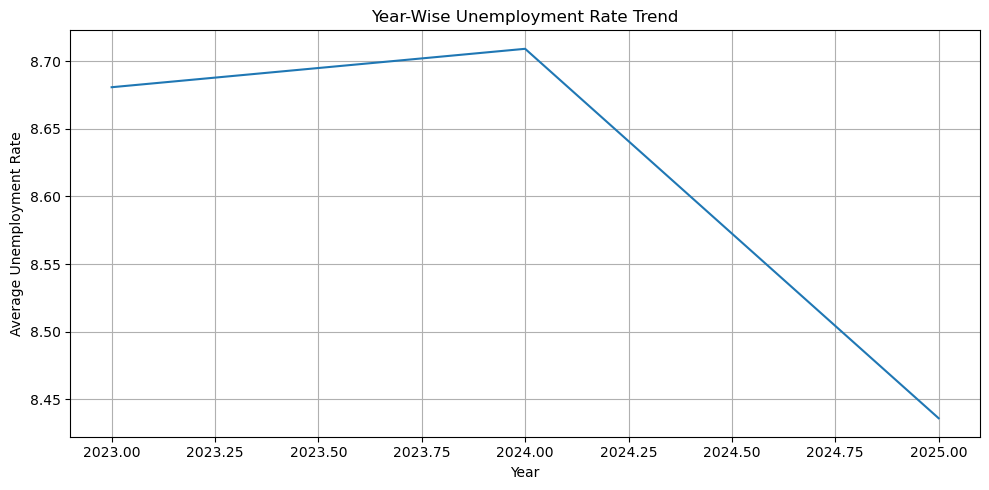

In [675]:
yearly_unemployment=(
    df.groupby('year')['Unemployment_Rate']
    .mean()
    .sort_index()
)
print(yearly_unemployment)

# Visualization

plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_unemployment.index,\
             y=yearly_unemployment.values,\
                markers='o')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate')
plt.title('Year-Wise Unemployment Rate Trend')
plt.grid(True)
plt.tight_layout()
plt.show()

-In 2023, the average unemployment rate was 8.68%.

-In 2024, the unemployment rate slightly increased to 8.71%.

-In 2025, the unemployment rate decreased to 8.44%.

This chart shows that the unemployment rate experienced a slight increase from 2023 to 2024, followed by a decrease in 2025. While the rise between 2023 and 2024 indicates a short-term increase in unemployment, the decline in 2025 suggests an improvement in job market conditions. These fluctuations highlight that unemployment levels vary over time and may be influenced by economic activity, job creation, and labor market dynamics. Such insights are useful for understanding employment trends and planning economic or workforce-related interventions.

#### 2) Quarter-Wise Unemployment Rate Analysis

quarter
1    9.060851
2    8.324889
3    8.608779
4    8.531655
Name: Unemployment_Rate, dtype: float64


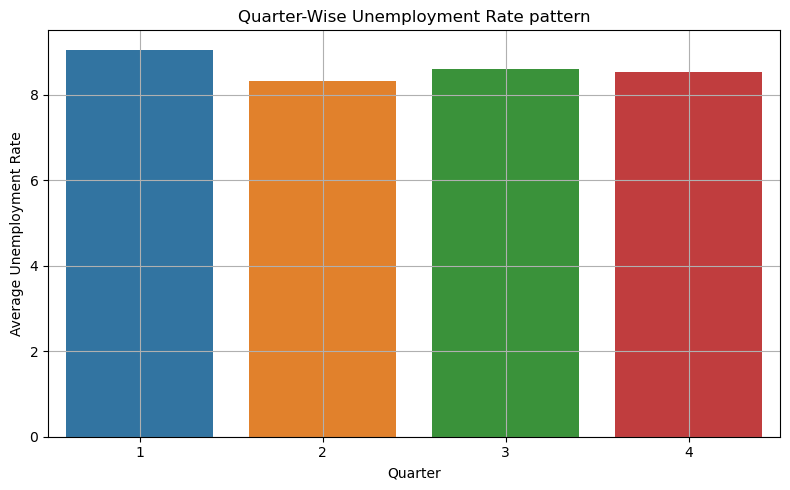

In [676]:
quarterly_unemployment=df.groupby('quarter')['Unemployment_Rate'].mean()
quarterly_unemployment=quarterly_unemployment.sort_index()
print(quarterly_unemployment)

# Visualization

plt.figure(figsize=(8,5))
sns.barplot(x=quarterly_unemployment.index,\
            y=quarterly_unemployment.values)
plt.xlabel('Quarter')
plt.ylabel('Average Unemployment Rate')
plt.title('Quarter-Wise Unemployment Rate pattern')
plt.grid(True)
plt.tight_layout()
plt.show()


In Quarter 1, the average unemployment rate is approximately 9.06%, which is the highest among all quarters.

In Quarter 2, unemployment decreases to around 8.32%, indicating an improvement in job market conditions.

Quarter 3 shows a moderate increase in unemployment to about 8.61%.

In Quarter 4, the unemployment rate slightly decreases to approximately 8.53%.

The quarter-wise analysis indicates clear seasonal variation in unemployment rates. Unemployment is highest during Quarter 1, suggesting reduced hiring activity at the beginning of the year. This is followed by a noticeable improvement in Quarter 2, while Quarter 3 experiences a moderate increase. By Quarter 4, unemployment levels stabilize at a slightly lower level. These patterns highlight the presence of seasonal effects in the job market, possibly influenced by industry cycles, fiscal planning periods, and hiring trends.

#### 3) Location-Wise Unemployment Rate Analysis

Location
San Diego        9.786667
Austin           9.240000
Jacksonville     9.157778
Los Angeles      9.055000
Fort Worth       9.004000
Houston          8.863158
Phoenix          8.842553
Dallas           8.749123
Columbus         8.715094
New York         8.629545
Charlotte        8.622917
Seattle          8.601613
Chicago          8.573214
San Francisco    8.375926
Denver           8.291667
San Antonio      8.271667
Washington       8.094737
San Jose         8.066038
Philadelphia     8.037500
Indianapolis     8.033333
Name: Unemployment_Rate, dtype: float64


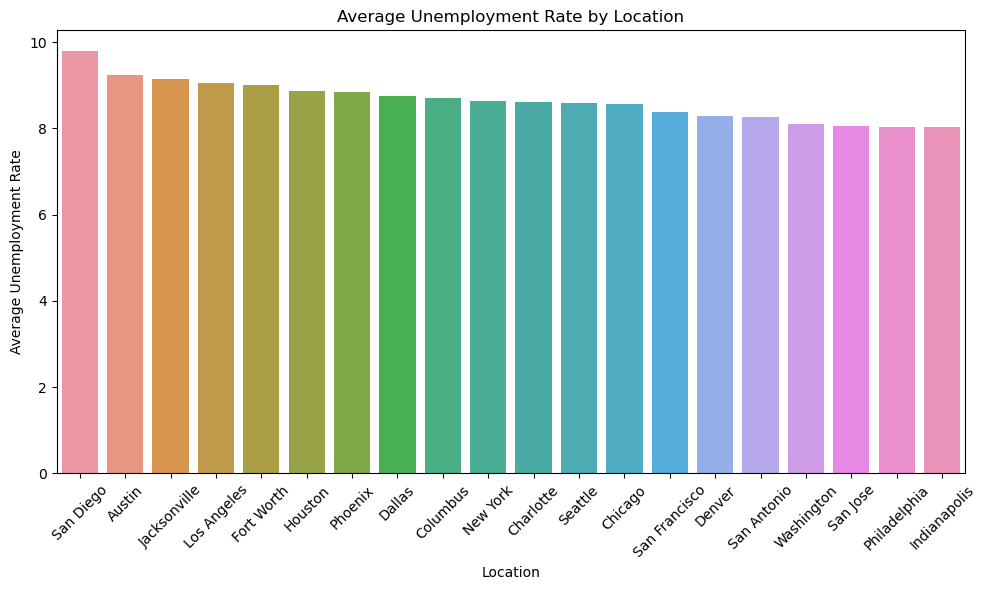

In [677]:
location_unemployment=(
    df.groupby('Location')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
)
print(location_unemployment)

# Visualization

plt.figure(figsize=(10,6))
sns.barplot(x=location_unemployment.index,\
            y=location_unemployment.values)
plt.xticks(rotation=45)
plt.xlabel('Location')
plt.ylabel('Average Unemployment Rate')
plt.title('Average Unemployment Rate by Location')
plt.tight_layout()
plt.show()

San Diego records the highest average unemployment rate at approximately 9.79%, indicating comparatively weaker job market conditions.

Austin and Jacksonville also show high unemployment rates of around 9.24% and 9.16% respectively.

Major cities such as Los Angeles and Fort Worth report unemployment rates slightly above 9%.

Mid-range values are observed in cities like Houston, Phoenix, and Dallas, where unemployment rates are between 8.7% and 8.9%.

Cities such as San Jose, Philadelphia, and Indianapolis show lower average unemployment rates, close to 8.0%, suggesting relatively better employment conditions.

The location-wise analysis highlights significant variation in unemployment rates across different cities. Some locations, such as San Diego and Austin, consistently experience higher unemployment, which may reflect regional economic challenges, industry concentration, or slower job creation. In contrast, cities with lower unemployment rates appear to have stronger job markets and better employment opportunities. These differences emphasize the importance of regional analysis when assessing overall job market conditions and identifying areas that may require targeted employment policies or interventions.


#### 4) Job Market Relationship Analysis 

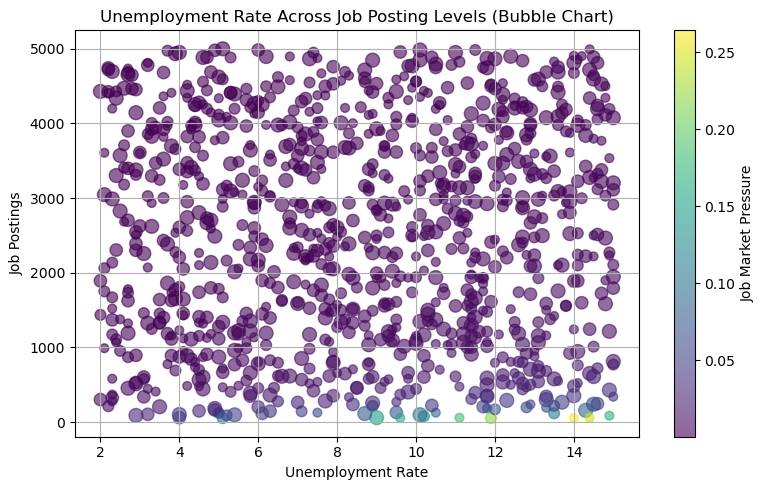

Summary Statistics:

       Unemployment_Rate  job_postings
count        1000.000000   1000.000000
mean            8.629700   2495.041000
std             3.704272   1438.082857
min             2.000000     53.000000
25%             5.400000   1212.750000
50%             8.800000   2497.500000
75%            11.800000   3779.000000
max            15.000000   4997.000000

Correlation:
0.019133011563499752


In [678]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['Unemployment_Rate'],
    df['job_postings'],
    s=df['Skill_Count']*20,
    c=df['Job_Market_Pressure'],
    cmap='viridis',
    alpha=0.6
)

plt.colorbar(label='Job Market Pressure')

plt.xlabel('Unemployment Rate')
plt.ylabel('Job Postings')
plt.title('Unemployment Rate Across Job Posting Levels (Bubble Chart)')

plt.grid(True)
plt.tight_layout()
plt.show()

print("Summary Statistics:\n")
print(df[['Unemployment_Rate','job_postings']].describe())

print("\nCorrelation:")
print(df['Unemployment_Rate'].corr(df['job_postings']))


The unemployment rate ranges from 2% to 15%, with an average of about 8.63%, while job postings vary widely from 53 to 4997.

The correlation between unemployment rate and job postings is very low (0.019), indicating almost no linear relationship.

The bubble chart also shows a scattered pattern without a clear trend.

Overall, unemployment and job postings are weakly related, suggesting other factors influence employment levels.

#### 5) Location-Wise Distribution of Job Postings

Top 5 Locations:

Location
Washington     155617
San Antonio    152792
Chicago        144629
San Jose       144600
Seattle        143147
Name: job_postings, dtype: int64


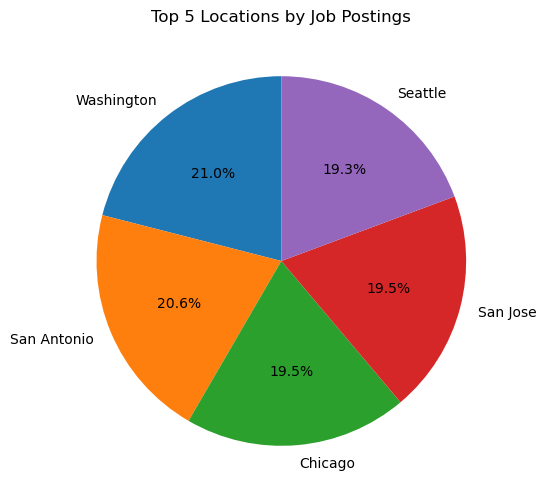

In [679]:
location_jobs=(
    df.groupby('Location')['job_postings']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print("Top 5 Locations:\n")
print(location_jobs)

# Visualization

plt.figure(figsize=(6,6))

plt.pie(
    location_jobs,
    labels=location_jobs.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 5 Locations by Job Postings')
plt.show()

Washington records the highest number of job postings (155,617), indicating strong hiring activity.

San Antonio and Chicago also show high job postings, each exceeding 140,000.

San Jose and Seattle follow closely, reflecting consistently strong job availability.

The pie chart highlights that a large share of job opportunities is concentrated in these top locations.

Overall, job postings are unevenly distributed, with a few major cities dominating employment opportunities.

#### 6) Impact of Education Level on Unemployment Rate

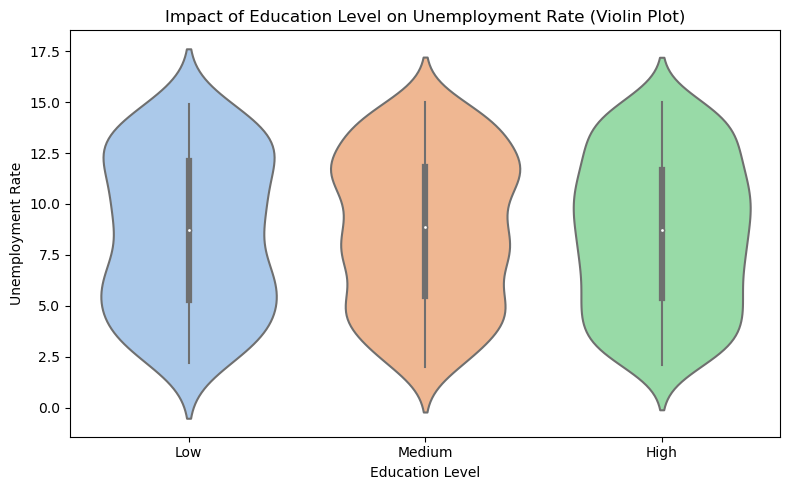

Average Unemployment Rate by Education Level:

Education_Level
Low       8.580247
Medium    8.731373
High      8.551860
Name: Unemployment_Rate, dtype: float64


In [680]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Education_Level',
    y='Unemployment_Rate',
    data=df,
    palette='pastel'
)

plt.xlabel('Education Level')
plt.ylabel('Unemployment Rate')
plt.title('Impact of Education Level on Unemployment Rate (Violin Plot)')

plt.tight_layout()
plt.show()

education_unemp = df.groupby('Education_Level')['Unemployment_Rate'].mean()
print("Average Unemployment Rate by Education Level:\n")
print(education_unemp)

The Low education group records an average unemployment rate of approximately 8.58%.

The Medium education group shows a slightly higher unemployment rate at around 8.73%.

The High education group has an average unemployment rate of about 8.55%, which is marginally lower than the other groups.

The box plot indicates a similar spread of unemployment rates across all education levels, with no extreme deviations.

Overall, unemployment rates remain fairly similar across education levels, with only minor variations. This suggests that while education has some influence, other factors also play a significant role in determining unemployment levels.

#### 7) Unemployment Rate Across Different Age Groups

Age Group Statistics:

               mean       std
Age_Group                    
Mid        8.756838  3.669840
Senior     8.406198  3.555150
Young      8.540000  3.978206


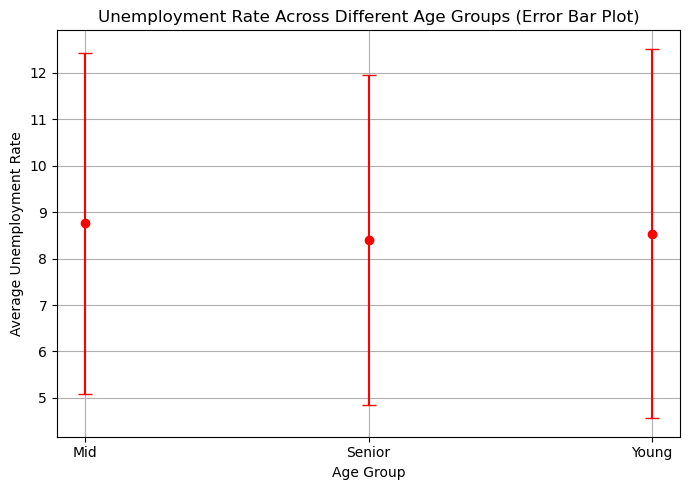

In [681]:
age_stats = df.groupby('Age_Group')['Unemployment_Rate'].agg(['mean','std'])
print("Age Group Statistics:\n")
print(age_stats)

plt.figure(figsize=(7,5))

plt.errorbar(
    age_stats.index,
    age_stats['mean'],
    yerr=age_stats['std'],
    fmt='o',
    capsize=5,
    color='red'
)

plt.xlabel('Age Group')
plt.ylabel('Average Unemployment Rate')
plt.title('Unemployment Rate Across Different Age Groups (Error Bar Plot)')

plt.grid(True)
plt.tight_layout()
plt.show()


The Mid age group records the highest average unemployment rate at approximately 8.76%.

The Young age group shows an average unemployment rate of around 8.54%, slightly lower than the mid group.

The Senior age group has the lowest unemployment rate at about 8.41%.

Overall differences across age groups are present but not very large.

Overall, unemployment rates vary slightly across age groups, with the mid age group experiencing marginally higher unemployment, while the senior group shows comparatively lower unemployment levels.

#### 8) Relationship Between Skill Diversity and Job Availability

Skill_Count
2    2434.371429
3    2509.439516
4    2495.152091
5    2541.204918
Name: job_postings, dtype: float64


C:\Users\AJEER\AppData\Local\Temp\ipykernel_25116\2564897174.py:10: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


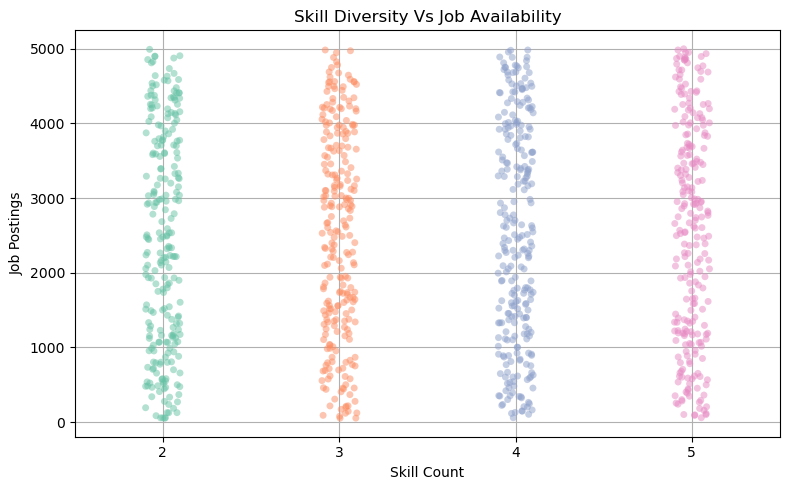

In [682]:
Skill_Job_Avg=(
    df.groupby('Skill_Count')['job_postings']
    .mean()
    .sort_index()
)
print(Skill_Job_Avg.head(10))

plt.figure(figsize=(8,5))

sns.stripplot(
    x='Skill_Count',
    y='job_postings',
    data=df,
    jitter=True,
    alpha=0.5,
    palette='Set2'
)

plt.xlabel('Skill Count')
plt.ylabel('Job Postings')
plt.title('Skill Diversity Vs Job Availability')

plt.grid(True)
plt.tight_layout()
plt.show()

When the skill count is 2, the average job postings are approximately 2434.

For 3 skills, average job postings increase to around 2509.

With 4 skills, job postings remain relatively high at about 2495.

The highest average job postings are observed for 5 skills, at approximately 2541.

The scatter plot shows that higher skill counts generally correspond to higher job availability, though some variability exists.

Overall, job availability tends to increase with higher skill diversity, suggesting that possessing a broader set of skills is associated with better employment opportunities, even though other factors also influence job postings.

#### 9) Location-Wise Unemployment Trends Over Time

   year      Location  Unemployment_Rate
0  2023        Austin           7.020000
1  2023     Charlotte           8.990000
2  2023       Chicago           7.680000
3  2023      Columbus          10.506250
4  2023        Dallas           9.033333
5  2023        Denver           8.017647
6  2023    Fort Worth           9.488889
7  2023       Houston           7.835714
8  2023  Indianapolis           7.928571
9  2023  Jacksonville           9.155556


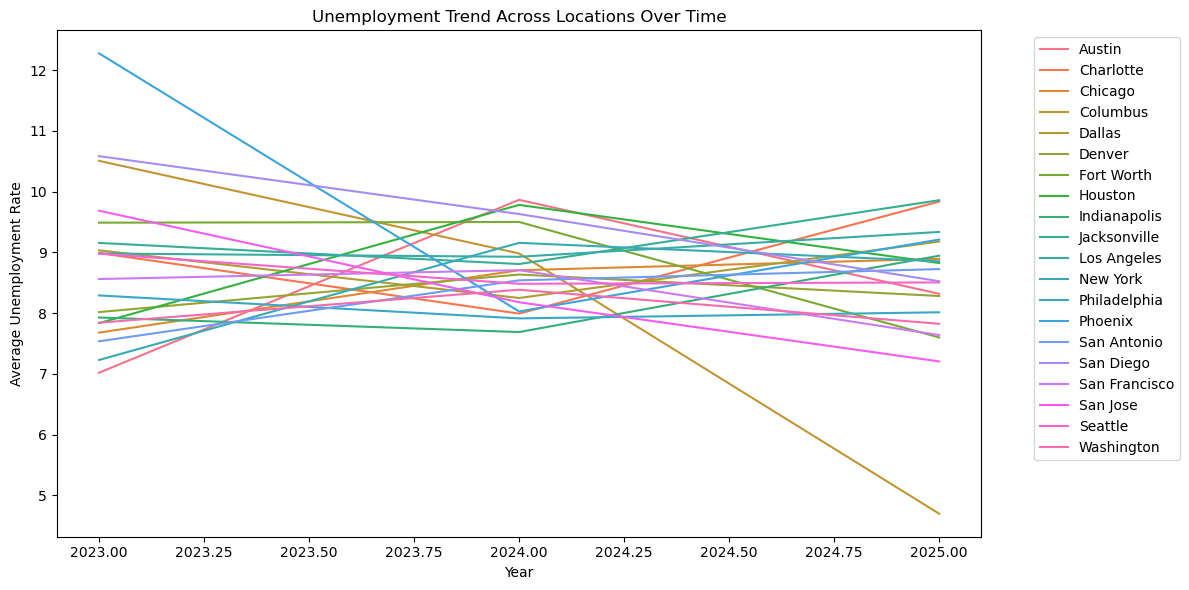

In [683]:
Location_Year_Unemp=(
    df.groupby(['year','Location'])['Unemployment_Rate']
    .mean()
    .reset_index()
)
print(Location_Year_Unemp.head(10))

# Visualization
plt.figure(figsize=(12,6))
sns.lineplot(
    data=Location_Year_Unemp,
    x='year',
    y='Unemployment_Rate',
    hue='Location'
)
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate')
plt.title('Unemployment Trend Across Locations Over Time')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()


In 2023, unemployment rates vary widely across locations, with Columbus showing a relatively higher unemployment rate compared to other cities.

From 2023 to 2024, several locations such as Austin and Houston show an increase in unemployment, while others remain relatively stable.

By 2025, some cities display a declining trend, whereas a few locations continue to show fluctuations.

Overall, no single pattern is common across all locations, indicating region-specific unemployment behavior.

Overall, unemployment trends differ noticeably across locations over time, highlighting that regional economic conditions play a significant role in shaping employment patterns.

#### 10) Distribution and Summary Statistics of Unemployment Rate and Job Postings

       Unemployment_Rate  job_postings
count        1000.000000   1000.000000
mean            8.629700   2495.041000
std             3.704272   1438.082857
min             2.000000     53.000000
25%             5.400000   1212.750000
50%             8.800000   2497.500000
75%            11.800000   3779.000000
max            15.000000   4997.000000


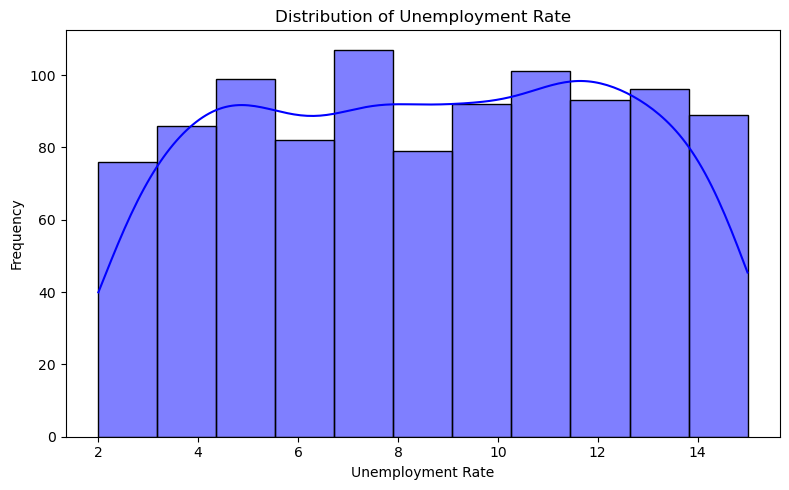

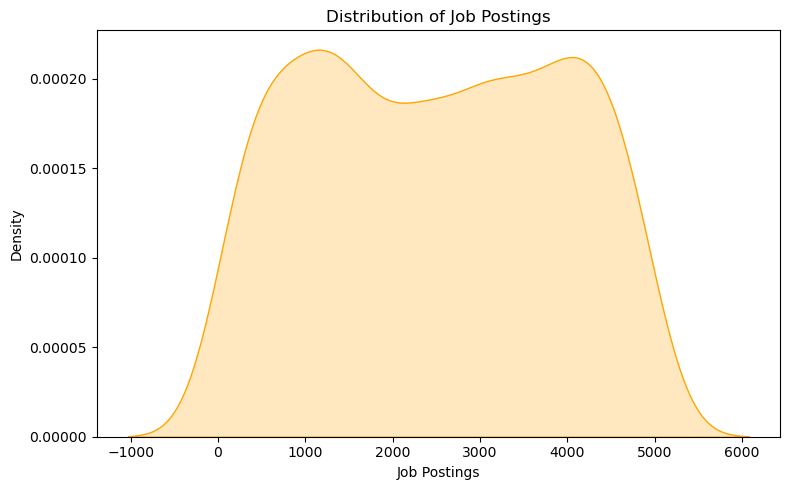

In [684]:
Summary_Stats=df[['Unemployment_Rate','job_postings']].describe()
print(Summary_Stats)

# Distribution of Unemployment Rate (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(
    df['Unemployment_Rate'],
    kde=True,
    color='blue'
)
plt.xlabel('Unemployment Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Unemployment Rate')
plt.tight_layout()
plt.show()

# Distribution of Job Postings (KDE Plot)

plt.figure(figsize=(8,5))

sns.kdeplot(
    df['job_postings'],
    fill=True,
    color='orange'
)

plt.xlabel('Job Postings')
plt.ylabel('Density')
plt.title('Distribution of Job Postings')

plt.tight_layout()
plt.show()

The unemployment rate is centered around 8–9%, with values spread between 2% and 15%.

The histogram shows a fairly even distribution of unemployment rates without extreme skewness.

Job postings display a wide range, from very low to very high values, as highlighted by the box plot.

The median job postings value is close to the mean, indicating a balanced central tendency with noticeable variability.

Overall, unemployment rates exhibit a relatively stable distribution, while job postings show greater variability, reflecting uneven job availability across locations and time periods.

### CONCLUSION

This exploratory data analysis examined job market and unemployment trends across different locations, time periods, and demographic factors. The analysis revealed that unemployment rates vary over time and show noticeable seasonal patterns across quarters. Location-wise comparisons highlighted clear regional differences, with some cities consistently experiencing higher unemployment rates, while others demonstrated relatively stronger employment conditions.

The relationship analysis showed that higher job postings are generally associated with lower unemployment rates, although this relationship is not perfectly linear, indicating the influence of additional economic factors. Education level and age group analyses suggested only minor differences in unemployment rates, implying that employment outcomes are shaped by multiple interacting variables rather than a single factor alone. Skill diversity analysis indicated that broader skill sets are often linked with increased job availability, reinforcing the importance of adaptability in the job market.

Overall, the findings emphasize that unemployment and job availability are influenced by a combination of temporal, regional, and skill-related factors. This study provides a clear understanding of employment patterns and highlights the value of exploratory data analysis in uncovering meaningful insights from real-world job market data. The insights derived from this analysis can support informed decision-making related to workforce planning, policy development, and regional employment strategies.